# Traffic density

Everything so far has placed aircraft by hand — a pair on a crossing, a ring of drones. This
notebook builds *traffic*: a field of aircraft crossing an area from all directions at a chosen
density, then asks what happens to safety as that density rises, with and without CNS uncertainty.

The traffic generator is the one described in:

> D.J. Groot, J. Ellerbroek and J.M. Hoekstra, "Analysis of the impact of traffic density on training
> of reinforcement learning based conflict resolution methods for drones", *Engineering Applications
> of Artificial Intelligence* **133** (2024) 108066.

We borrow only their **scenario geometry** — the entry-bearing rule of their Fig. 4 (left), the two
concentric areas, and the density bookkeeping. Their study is about reinforcement learning resolving
*vertical* manoeuvres in a layered airspace; what follows is a purely horizontal study with the
resolvers this library ships. So the numbers here are not comparable with theirs, and are not meant
to be — the geometry is what carries over.

In [1]:
%matplotlib inline
import dataclasses
import math

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    FTR, M600, MVP, Agent, Comm, GnssNavigation, LastKnown, StateBased,
    create_aircraft, generator, root_seed_sequence, run_fleet, spawn,
)
from opencdarr.cns import BroadcastSchedule, lognormal_latency
from opencdarr.geo import forward, qdrdist

CENTRE = (52.0, 4.0)

# Two concentric discs, as in the paper. Aircraft live in the simulation area; measurements are
# only taken inside the smaller experimental area. The ratio is the paper's 1.35 NM / 1.62 NM.
R_OUTER = 1000.0                       # simulation area [m] -- traffic density is defined over this
R_INNER = R_OUTER * (1.35 / 1.62)      # experimental area [m] -- dependent measures only in here

SPEED = 10.0        # m/s, constant, as in the paper
RPZ = 50.0          # m horizontal separation minimum, as in the paper
T_WARMUP = 30.0     # s discarded before measuring, so the artificial t=0 layout is not counted

print(f"simulation area   r = {R_OUTER:7.1f} m   {math.pi * (R_OUTER / 1000) ** 2:.3f} km²")
print(f"experimental area r = {R_INNER:7.1f} m   {math.pi * (R_INNER / 1000) ** 2:.3f} km²")
print(f"ratio {R_INNER / R_OUTER:.4f}   (paper: 1.35 / 1.62 = {1.35 / 1.62:.4f})")

simulation area   r =  1000.0 m   3.142 km²
experimental area r =   833.3 m   2.182 km²
ratio 0.8333   (paper: 1.35 / 1.62 = 0.8333)


## Where aircraft enter, and why it is not obvious

The obvious way to start an aircraft at the edge of a circular area is to pick a random point on the
perimeter and a random heading. That turns out to be wrong, and the reason is worth understanding
before writing any code.

An aircraft that enters near the edge *tangentially* clips a short corner of the area and leaves
almost immediately. One that enters aimed at the centre crosses the full diameter. If entry points
are spread evenly around the perimeter, the short-corner flights are heavily over-represented — so
traffic piles up near the border and the middle of the area stays comparatively empty.

The fix used in the paper is their Fig. 4 (left), **uniform linear projected onto the half-circle**.
Instead of spreading entry points evenly along the perimeter, spread them evenly along a *diameter*
and project each one out to the circle. Their Eq. (8) is:

$$\text{entry bearing} = \text{heading} + 180° + \arcsin(x), \qquad x \sim \mathcal{U}[-1, 1]$$

The `arcsin` is doing all the work. A drone entering at bearing `heading + 180°` flies straight
through the centre; the `arcsin(x)` term swings the entry point around by an angle whose *sine* is
uniform. Since the perpendicular distance from the centre to that flight path is exactly
`R · sin(arcsin(x)) = R · x`, making `x` uniform makes the **miss distance from the centre uniform
across the diameter**. That is the whole trick.

Heading itself is drawn uniformly over 0–360°, so the traffic has no preferred direction.

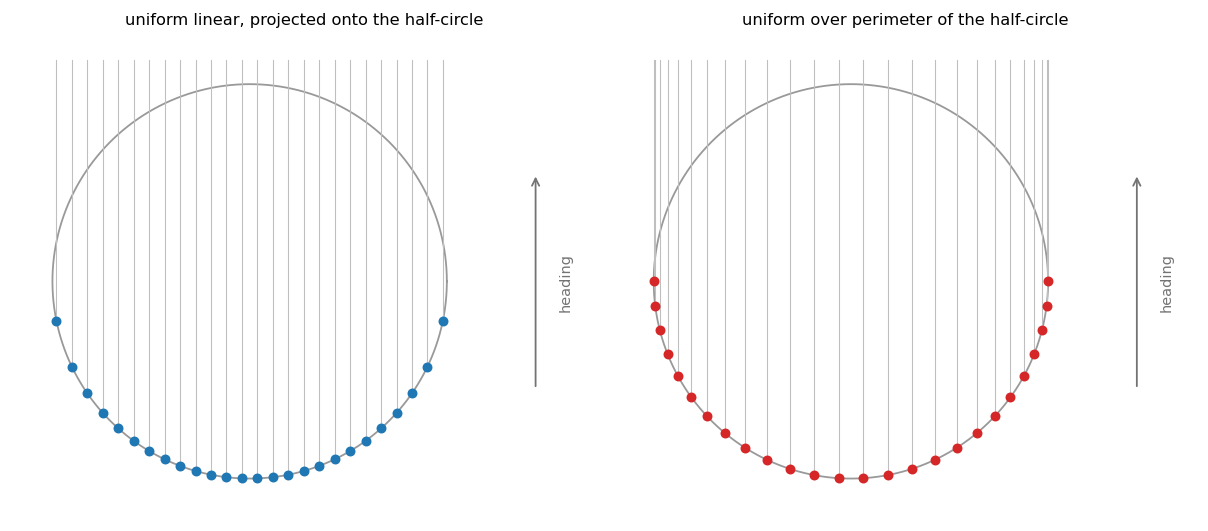

In [2]:
def entry_points(n, rng, mode):
    # Entry bearing (deg, from the centre) and heading (deg) for n aircraft.
    heading = rng.uniform(0.0, 360.0, n)
    if mode == "linear":
        x = rng.uniform(-1.0, 1.0, n)
        bearing = (heading + 180.0 + np.degrees(np.arcsin(x))) % 360.0    # Eq (8)
    else:
        bearing = rng.uniform(0.0, 360.0, n)                              # even around the rim
    return bearing, heading


# Reproduce the paper's Fig. 4: deterministic, evenly spaced samples of each rule
fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.4, 5.0))
th = np.linspace(0, 2 * np.pi, 400)

x = np.linspace(-0.98, 0.98, 26)                       # even along the diameter
axL.plot(np.cos(th), np.sin(th), color="0.6", lw=1.0)
for xi in x:
    axL.plot([xi, xi], [-np.sqrt(1 - xi ** 2), 1.12], color="0.75", lw=0.6)
axL.plot(x, -np.sqrt(1 - x ** 2), "o", ms=4.5, color="#1f77b4")
axL.set_title("uniform linear, projected onto the half-circle", fontsize=9)

a = np.linspace(np.pi, 2 * np.pi, 26)                  # even around the rim
axR.plot(np.cos(th), np.sin(th), color="0.6", lw=1.0)
for ai in a:
    axR.plot([np.cos(ai), np.cos(ai)], [np.sin(ai), 1.12], color="0.75", lw=0.6)
axR.plot(np.cos(a), np.sin(a), "o", ms=4.5, color="#d62728")
axR.set_title("uniform over perimeter of the half-circle", fontsize=9)

for ax in (axL, axR):
    ax.set_aspect("equal")
    ax.set_xlim(-1.2, 1.75)
    ax.set_ylim(-1.2, 1.25)
    ax.axis("off")
    ax.annotate("", xy=(1.45, 0.55), xytext=(1.45, -0.55),
                arrowprops=dict(arrowstyle="->", lw=1.0, color="0.45"))
    ax.text(1.60, 0.0, "heading", rotation=90, va="center", ha="center",
            fontsize=8, color="0.45")
fig.tight_layout()

Left is the paper's rule: the vertical lines are evenly spaced, so where they *meet the circle* the
points bunch up towards the sides. Right is the naive rule: points evenly spaced around the rim, so
the lines bunch up in the middle instead.

That bunching is the entire difference, and it is easy to check which one is right. Take each rule,
fly the aircraft in a straight line across the area, and look at where the traffic actually ends up.
For a genuinely uniform spread over a disc, the fraction of aircraft inside radius `r` should go as
`r²` — so plotting `(r/R)²` should give a straight diagonal.

  uniform linear (paper):  mean (r/R)² = 0.4998
  uniform over perimeter:  mean (r/R)² = 0.5566

uniform over the disc:      mean (r/R)² = 0.5000


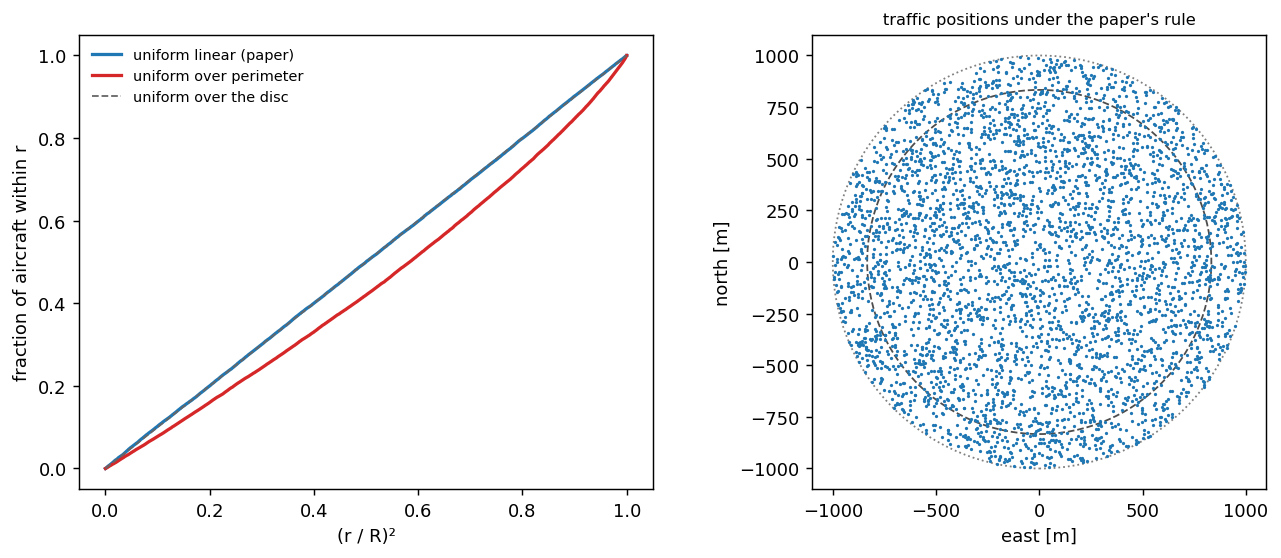

In [3]:
def steady_state(n, rng, radius, mode):
    # Where the traffic actually is, in steady state, under a given entry rule.
    # An aircraft contributes in proportion to the time it spends inside, i.e. to its chord length.
    m = 40 * n + 20000
    bearing, heading = entry_points(m, rng, mode)
    br, hr = np.radians(bearing), np.radians(heading)
    px, py = radius * np.sin(br), radius * np.cos(br)       # entry point, east/north
    ux, uy = np.sin(hr), np.cos(hr)                         # unit heading
    chord = -2.0 * (px * ux + py * uy)                      # distance to the far side
    keep = chord > 1.0                                      # drop outbound / grazing draws
    px, py, ux, uy, chord, heading = (v[keep] for v in (px, py, ux, uy, chord, heading))
    idx = rng.choice(chord.size, size=n, p=chord / chord.sum())
    s = rng.uniform(0.0, 1.0, n) * chord[idx]               # uniform along its own chord
    return px[idx] + ux[idx] * s, py[idx] + uy[idx] * s, heading[idx], chord[idx]


rng = np.random.default_rng(0)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.4, 4.4))

for mode, colour, label in (("linear", "#1f77b4", "uniform linear (paper)"),
                            ("perimeter", "#d62728", "uniform over perimeter")):
    e, n_, _, _ = steady_state(40000, np.random.default_rng(1), R_OUTER, mode)
    r2 = (e ** 2 + n_ ** 2) / R_OUTER ** 2
    ax0.plot(np.sort(r2), np.linspace(0, 1, r2.size), lw=1.8, color=colour, label=label)
    print(f"{label:>24}:  mean (r/R)² = {r2.mean():.4f}")

ax0.plot([0, 1], [0, 1], ls="--", lw=1.0, color="0.4", label="uniform over the disc")
ax0.set_xlabel("(r / R)²")
ax0.set_ylabel("fraction of aircraft within r")
ax0.legend(frameon=False, fontsize=8)

e, n_, _, _ = steady_state(4000, np.random.default_rng(2), R_OUTER, "linear")
ax1.plot(e, n_, ".", ms=1.6, color="#1f77b4")
ax1.add_patch(plt.Circle((0, 0), R_OUTER, fill=False, color="0.5", lw=1.0, ls=":"))
ax1.add_patch(plt.Circle((0, 0), R_INNER, fill=False, color="0.3", lw=1.0, ls="--"))
ax1.set_aspect("equal")
ax1.set_xlabel("east [m]")
ax1.set_ylabel("north [m]")
ax1.set_title("traffic positions under the paper's rule", fontsize=9)
fig.tight_layout()
print("\nuniform over the disc:      mean (r/R)² = 0.5000")

The paper's rule lands exactly on the diagonal — the traffic is uniform over the disc, which is what
it was designed to do. The perimeter rule bows above it: too many aircraft close to the edge, too
few in the middle, exactly the bias the paper describes.

The right panel shows the resulting traffic, with the two areas marked: the dotted circle is the
**simulation area**, the dashed one the **experimental area**.

## Two areas, not one

This is the second thing to take from the paper's setup. Aircraft occupy the full simulation area,
but *dependent measures are only recorded within the smaller experimental area*. The annulus between
the two is a buffer: traffic entering the outer edge has room to sort itself out before it reaches
the region where anything is counted, so measurements are not polluted by aircraft that have only
just appeared.

Traffic density is defined over the **outer** disc, so the number of aircraft is
`density × π R_outer²`. (In the paper's Table 1, 25 AC/NM² over their 1.62 NM disc gives 206
aircraft, which is where this bookkeeping comes from.)

Two adjustments are needed to run this in OpenCDaRR, and both are worth being explicit about:

- **`run_fleet` flies a fixed list of aircraft; it cannot spawn new ones mid-run.** So instead of
  spawning continuously at the border, we place the whole fleet in the steady state that process
  converges to — which is exactly what the cell above computed and verified.
- **A snapshot can place two aircraft on top of each other.** With 63 aircraft dropped at random
  into this disc, roughly five pairs would start closer than 50 m to each other by pure chance, and
  those would be counted as intrusions before anyone had done anything wrong. So the layout is
  rejection-sampled to start every aircraft at least `2 × RPZ` from its neighbours, and the first
  `T_WARMUP` seconds are discarded.

In [4]:
def traffic_fleet(density, seed, pos_ci95=0.0, vel_ci95=0.0, mode="linear", min_spacing=2 * RPZ):
    # A steady-state snapshot of traffic at `density` aircraft per km² of the simulation area.
    rng = np.random.default_rng(seed)
    n = max(2, round(density * math.pi * (R_OUTER / 1000.0) ** 2))
    east, north, heading = [], [], []
    tries = 0
    while len(east) < n and tries < 500 * n:
        e, no, h, _ = steady_state(1, rng, R_OUTER, mode)
        tries += 1
        if east and min(math.hypot(e[0] - a, no[0] - b) for a, b in zip(east, north)) < min_spacing:
            continue                                   # too close to start: draw another
        east.append(float(e[0])); north.append(float(no[0])); heading.append(float(h[0]))
    if len(east) < n:
        raise RuntimeError(f"could not place {n} aircraft {min_spacing:.0f} m apart")

    perf = dataclasses.replace(M600, v_max=SPEED, v_min=-SPEED)
    agents = []
    for i in range(n):
        bearing = math.degrees(math.atan2(east[i], north[i])) % 360.0
        lat, lon = forward(*CENTRE, bearing, math.hypot(east[i], north[i]))
        agents.append(Agent(create_aircraft(
            perf, id=f"A{i:03d}", lat=lat, lon=lon, trk=heading[i], gs=SPEED,
            pos_ci95=pos_ci95, vel_ci95=vel_ci95), perf))
    return agents


def fly(agents, cns_seed=None, dt=1.0, t_max=150.0):
    kw = dict(rpz=RPZ, t_lookahead=20.0, dt=dt, detector=StateBased(), resolver=MVP(1.05),
              recovery=FTR(), t_max=t_max, done_timeout=1e9, record=True)
    if cns_seed is not None:
        nav, comm, bc = spawn(root_seed_sequence(cns_seed), 3)
        kw |= dict(navigation=GnssNavigation(), rng=generator(nav),
                   communication=Comm(reception_prob=0.9, latency=lognormal_latency(0.2, 0.4)),
                   comm_rng=generator(comm), surveillance=LastKnown(),
                   schedule=BroadcastSchedule(interval=1.0), broadcast_rng=generator(bc))
    return run_fleet(agents, **kw)


def positions(run):
    # (T, N, 2) east/north of the centre, in metres.
    frames = run.frames.frames
    out = np.empty((len(frames), len(frames[0].states), 2))
    for i, f in enumerate(frames):
        for k, s in enumerate(f.states):
            qdr, dist = qdrdist(*CENTRE, s.lat, s.lon)
            a = math.radians(qdr)
            out[i, k] = (dist * math.sin(a), dist * math.cos(a))
    return out


def measure(run):
    # Closest approach of every pair, counted only while BOTH are inside the experimental
    # area and the warm-up has passed. Pairs never jointly eligible come back as inf.
    p = positions(run)
    t = np.array([f.t for f in run.frames.frames])
    eligible = (np.hypot(p[..., 0], p[..., 1]) <= R_INNER) & (t >= T_WARMUP)[:, None]
    d = np.linalg.norm(p[:, :, None, :] - p[:, None, :, :], axis=-1)
    both = eligible[:, :, None] & eligible[:, None, :]
    iu = np.triu_indices(p.shape[1], k=1)
    dmin = np.where(both, d, np.inf)[:, iu[0], iu[1]].min(axis=0)
    return dmin[np.isfinite(dmin)]


for d in (5, 10, 15, 20, 25):
    print(f"density {d:>3} AC/km²  ->  {round(d * math.pi * (R_OUTER / 1000) ** 2):>3} aircraft")

density   5 AC/km²  ->   16 aircraft
density  10 AC/km²  ->   31 aircraft
density  15 AC/km²  ->   47 aircraft
density  20 AC/km²  ->   63 aircraft
density  25 AC/km²  ->   79 aircraft


## The traffic, with and without CNS uncertainty

Here is one density, flown twice from an identical starting layout. The first run gives every
aircraft perfect knowledge of the others. The second puts the standard CNS stack in the way:

| | model | what it does |
|---|---|---|
| **C** | `Comm` | broadcasts each aircraft's report once a second; one in ten is lost, delivery is delayed |
| **N** | `GnssNavigation` | each aircraft measures **its own** state to 10 m and 1 m/s (95%) |
| **S** | `LastKnown` | a receiver believes the last message it got, held as-is until the next |

 perfect information:  320 interacting pairs, closest   50.4 m, 0 intrusion(s)
        standard CNS:  345 interacting pairs, closest   51.9 m, 0 intrusion(s)


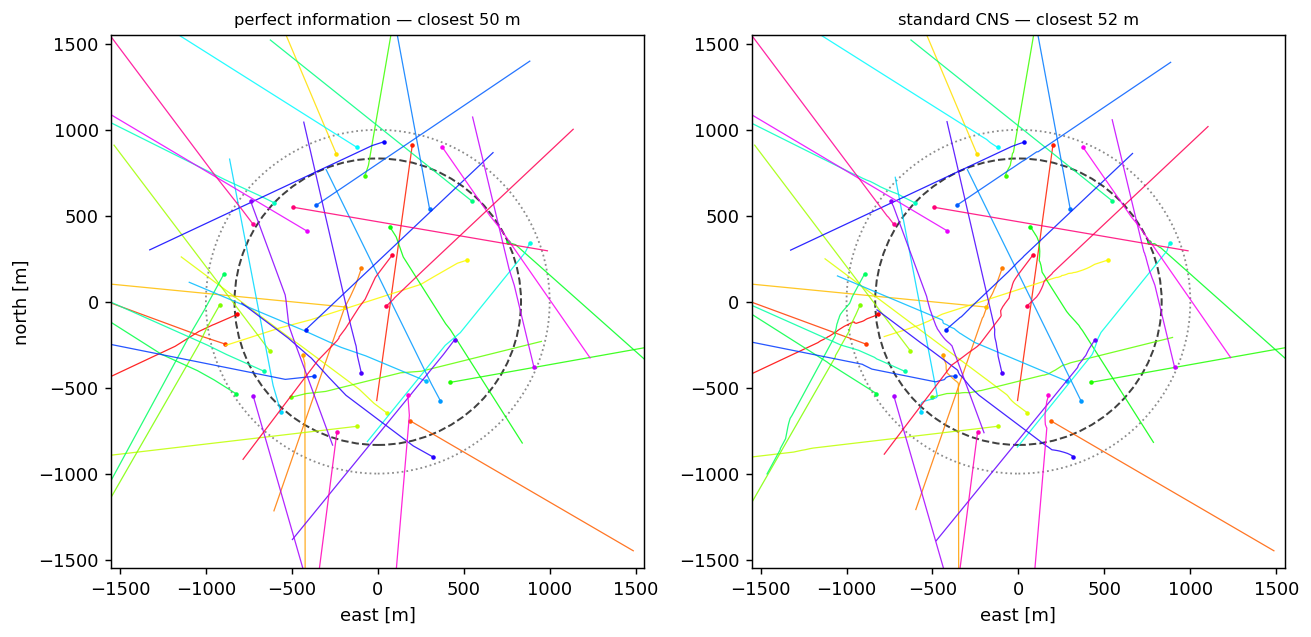

In [5]:
DEMO_DENSITY = 15

clean = fly(traffic_fleet(DEMO_DENSITY, seed=0))
noisy = fly(traffic_fleet(DEMO_DENSITY, seed=0, pos_ci95=10.0, vel_ci95=1.0), cns_seed=0)


def draw_traffic(ax, run, title):
    p = positions(run)
    n = p.shape[1]
    for k in range(n):
        ax.plot(p[:, k, 0], p[:, k, 1], lw=0.7, color=plt.cm.hsv(k / n), alpha=0.85)
        ax.plot(p[0, k, 0], p[0, k, 1], ".", ms=3, color=plt.cm.hsv(k / n))
    ax.add_patch(plt.Circle((0, 0), R_OUTER, fill=False, color="0.55", lw=1.0, ls=":"))
    ax.add_patch(plt.Circle((0, 0), R_INNER, fill=False, color="0.25", lw=1.1, ls="--"))
    ax.set_aspect("equal")
    ax.set_xlim(-1.55 * R_OUTER, 1.55 * R_OUTER)
    ax.set_ylim(-1.55 * R_OUTER, 1.55 * R_OUTER)
    ax.set_xlabel("east [m]")
    ax.set_title(title, fontsize=9)


fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.2, 5.3))
d_clean, d_noisy = measure(clean), measure(noisy)
draw_traffic(ax0, clean, f"perfect information — closest {d_clean.min():.0f} m")
draw_traffic(ax1, noisy, f"standard CNS — closest {d_noisy.min():.0f} m")
ax0.set_ylabel("north [m]")
fig.tight_layout()

for tag, d in (("perfect information", d_clean), ("standard CNS", d_noisy)):
    print(f"{tag:>20}: {d.size:>4} interacting pairs, closest {d.min():6.1f} m, "
          f"{int((d < RPZ).sum())} intrusion(s)")

The dotted circle is the simulation area, the dashed one the experimental area where measurements
are taken. Dots mark where each aircraft started.

On the left the tracks are near-straight: aircraft fly their heading, make a small deviation where
paths would have crossed too closely, and carry on. On the right the same fleet visibly wobbles —
each aircraft is steering off a picture of its neighbours that is a little wrong and up to a second
old, so it keeps re-deciding, and the corrections show up as kinks along every track.

## Turning the density up

Now sweep it. Each density is run from three different traffic layouts, once with perfect
information and once with CNS.

In [6]:
DENSITIES = [5, 10, 15, 20, 25]
SEEDS = [0, 1, 2]

sweep = {}
for dens in DENSITIES:
    for tag, kw, cs in (("perfect", {}, None),
                        ("cns", dict(pos_ci95=10.0, vel_ci95=1.0), True)):
        pooled = []
        for s in SEEDS:
            run = fly(traffic_fleet(dens, seed=s, **kw), cns_seed=(s if cs else None))
            pooled.append(measure(run))
        sweep[dens, tag] = np.concatenate(pooled)

print(f"{'density':>8} {'aircraft':>9} | {'pairs':>6} {'closest':>9} {'5th pct':>9} {'intrusions':>11}"
      f" | {'pairs':>6} {'closest':>9} {'5th pct':>9} {'intrusions':>11}")
print(f"{'':>8} {'':>9} | {'--- perfect information ---':^38} | {'--- standard CNS ---':^38}")
for dens in DENSITIES:
    n_ac = round(dens * math.pi * (R_OUTER / 1000) ** 2)
    row = f"{dens:>8} {n_ac:>9} |"
    for tag in ("perfect", "cns"):
        d = sweep[dens, tag]
        row += (f" {d.size:>6} {d.min():>7.2f} m {np.percentile(d, 5):>7.1f} m "
                f"{int((d < RPZ).sum()):>11} |")
    print(row)

 density  aircraft |  pairs   closest   5th pct  intrusions |  pairs   closest   5th pct  intrusions
                   |      --- perfect information ---       |          --- standard CNS ---         
       5        16 |    150   50.76 m    90.8 m           0 |    150   58.28 m    90.4 m           0 |
      10        31 |    504   50.21 m    79.9 m           0 |    504   56.84 m    92.2 m           0 |
      15        47 |   1259   50.41 m    99.2 m           0 |   1311   51.90 m   106.6 m           0 |
      20        63 |   2340   50.04 m    95.3 m           0 |   2378   55.49 m   103.4 m           0 |
      25        79 |   3915   49.98 m    96.4 m           1 |   4235   49.16 m    94.5 m           1 |


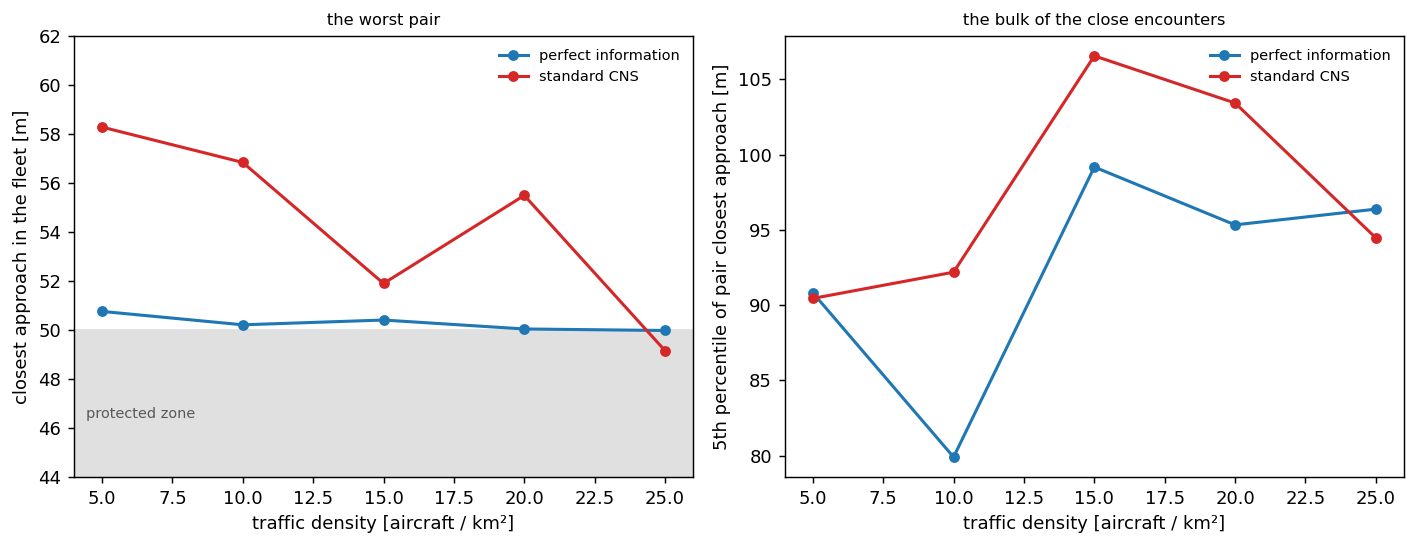

In [7]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.0, 4.3))
STYLE = {"perfect": ("#1f77b4", "perfect information"), "cns": ("#d62728", "standard CNS")}

for tag, (colour, label) in STYLE.items():
    ax0.plot(DENSITIES, [sweep[d, tag].min() for d in DENSITIES],
             marker="o", ms=5, lw=1.7, color=colour, label=label)
    ax1.plot(DENSITIES, [np.percentile(sweep[d, tag], 5) for d in DENSITIES],
             marker="o", ms=5, lw=1.7, color=colour, label=label)

ax0.axhspan(0, RPZ, color="0.88", zorder=0)
ax0.set_ylim(44, 62)          # the whole story lives in a ~12 m band just above the zone
ax0.annotate("protected zone", (0.02, 46.4), xycoords=("axes fraction", "data"),
             ha="left", fontsize=8, color="0.35")
ax0.set_ylabel("closest approach in the fleet [m]")
ax0.set_title("the worst pair", fontsize=9)

ax1.set_ylabel("5th percentile of pair closest approach [m]")
ax1.set_title("the bulk of the close encounters", fontsize=9)

for ax in (ax0, ax1):
    ax.set_xlabel("traffic density [aircraft / km²]")
    ax.legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()

The headline is how *little* moves in the left panel.

**With perfect information the worst pair sits on the protected zone at every density.** It is 50.76 m
at 5 aircraft per km² and 49.98 m at 25 — under a metre of drift while the traffic quintuples. That is
`FTR` doing exactly what it says: it resumes as soon as reverting to the original heading would keep
the pair clear, so the fleet rides the boundary rather than banking margin it does not need. Density
barely enters into it, because MVP resolves each conflict to the same target no matter how many of
them there are.

**At this level of uncertainty, CNS mostly helps.** The noisy fleet's worst pair is *above* the
perfect-information one at four of the five densities, by up to 7.5 m at the low end. An aircraft
steering from a 10 m position error resolves against conflicts that were not quite real and starts
avoiding earlier than it strictly needed to, and that over-avoidance banks margin the
perfect-information fleet deliberately gives back.

The right panel broadly agrees, though less cleanly. The 5th percentile is clearly higher under CNS
across the middle of the range — by 8 to 12 m at 10, 15 and 20 aircraft per km² — but the two are
level at the lowest density (90.4 m against 90.8 m, a difference of no consequence) and CNS is lower
at the top. The over-avoidance story holds where there is room for it and stops holding at both ends
of the range, for different reasons.

**Only at 25 aircraft per km² does it turn over**, where the noisy worst pair slips just below the
perfect one and the 5th percentile crosses too. That is the density at which the extra manoeuvring
starts costing more than it buys — each unnecessary avoidance nudging an aircraft towards its other
neighbours.

**One intrusion apiece at the top density is not a difference between the two.** Both conditions
record exactly one, from three layouts each. The honest reading of this sweep is that at 10 m and
1 m/s the two are hard to tell apart: uncertainty of this size is comfortably inside what MVP
absorbs, and it shifts the margin around without breaking it. Turn the errors up and that stops
being true.

Two things worth keeping in view before generalising any of it. The intrusion counts are single
digits, so they can show that intrusions begin to appear around the top of this density range but
cannot support a rate — that needs many more layouts, or the rare-event estimator. And these runs
use `dt = 1.0`; dense traffic is timestep-sensitive, so a finding worth keeping should be re-checked
at `dt = 0.5` first.

## Things to try from here

- **Change the density grid.** `DENSITIES` is the parameter. Cost grows with the square of the
  aircraft count, so doubling density roughly quadruples the runtime of a point.
- **Use the naive entry rule.** `traffic_fleet(..., mode="perimeter")` builds traffic with the
  edge-heavy bias, so you can measure how much the scenario-generation choice moves your results —
  the question the paper's Fig. 4 exists to settle.
- **Separate the two uncertainties.** Set `reception_prob=1.0` and zero latency while keeping
  `pos_ci95`, to split "I cannot see you accurately" from "I cannot hear you reliably".
- **Swap the resolver.** `VO(1.05)` takes the same slot as `MVP(1.05)`.
- **Check the timestep.** These runs use `dt = 1.0`. Dense traffic can be timestep-sensitive, so
  before trusting any single finding here, rerun the point at `dt = 0.5` and confirm it survives.